In [1]:
import socket
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import psutil
#import pygetdata as gd
import os
import time
import struct
import sys
from threading import Thread
import astropy.io.fits as pyfits
import queen_tui

Error loading firmware: No module named 'xrfdc'


In [2]:
10*np.log10(1000/5)

23.010299956639813

In [3]:
sys.path.append('/usr/lib/python3/')

In [4]:
UDP_IP = "192.168.3.40"

UDP_PORT = 4096

In [5]:
sock = socket.socket(socket.AF_INET, # Internet

           socket.SOCK_DGRAM) # UDP

sock.bind((UDP_IP, UDP_PORT)) 

In [6]:
def capturePacket(byteshift=-1):
    """
    Q - Remove byte rolling and conversion to separate function?
    """

    data = sock.recv(9000) # buffer size is 1024 bytes

    data = bytearray(data)

    data = np.roll(data,byteshift)

    return np.frombuffer(data, dtype="<i").astype("float")


def getNpackets(N,byteshift=-1):

    packets = capturePacket(byteshift)

    for p in range(N):

        newPacket = capturePacket(byteshift)

        packets = np.vstack([packets,newPacket])

    return packets


def getNpackets_2(N,byteshift=-1):
    
    return np.array([capturePacket(byteshift) for p in range(N)])

def livePlot():
    from matplotlib import pyplot as plt
    from IPython.display import clear_output
    import numpy as np
    plt.figure()
    for i in range(10):
        clear_output(wait=True)
        y=getNpackets_2(48)
        print (i)
        print (y.shape)
        #for j in range(1):
        #plt.plot(range(i*48,(i+1)*48),y[:, 16+1*2]**2.0+y[:, 17+1*2]**2.0)
        plt.plot(y[:, 16+1*2]**2.0+y[:, 17+1*2]**2.0)
        plt.show()

        
        
def saveDirfileIQ(time_interval):
    data_path = "./" #self.gc[np.where(self.gc == 'DIRFILE_SAVEPATH')[0][0]][1]
    sub_folder = input("Insert subfolder name (e.g. single_tone): ")
    data_rate = 512e6/2**20
    Npackets = np.ceil(time_interval * data_rate)
    Npackets = int(np.ceil(Npackets))
    save_path = os.path.join(data_path, sub_folder)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    filename = save_path + '/' + \
               str(int(time.time())) + '-' + time.strftime('%b-%d-%Y-%H-%M-%S') + '.dir'
    # make the dirfile
    d = gd.dirfile(filename,gd.CREAT|gd.RDWR|gd.UNENCODED)
    d.add_spec('I RAW FLOAT32 1')
    d.add_spec('Q RAW FLOAT32 1')
    d.close()
    d = gd.dirfile(filename,gd.RDWR|gd.UNENCODED)
    i_file = open(filename + "/I", "ab")
    q_file = open(filename + "/Q", "ab")
    count = 0
    while count < Npackets:
        p = capturePacket()
        I, Q = p[16], p[17]
        i_file.write(struct.pack('<f', I))
        q_file.write(struct.pack('<f', Q))
        i_file.flush()
        q_file.flush()
        d.flush()
        count += 1
    i_file.close()
    q_file.close()
    d.close()
    return





In [ ]:
t_sec = 30.0
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
p=getNpackets_2(N_packet)

In [ ]:
np.save('/home/rfsoc/rfsoc_result/Colin/20230725/20230725_timestream_80mK_30dBamp_77K_blackbody_30s.npy',p)

In [ ]:
%matplotlib notebook
for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='r', label='0')

In [ ]:
p=getNpackets_2(8000)
p.shape

In [7]:
sys.path.append('/home/rfsoc/fts/')
from fts_control_script import Motor

# Worker FTS control function to run in a thread while detector data is being collected
def fts_worker_func(motor):
    motor.run_passes()
    return

# Worker function to send a "clap" signal and remember the time it finished,
# running in a thread so that timestream packet collection isn't interrupted
def clap_worker_func(thread_output):
    os.system('python3 queen_tui.py 21 1.1 -a 1')
    os.system('python3 queen_tui.py 21 1.1 -a 0')
    thread_output.append(time.time())
    return

passes = 6
dist = 160
speed = 20
motor = Motor(passes=passes, dist=dist, speed=speed, sample_rate=50)
motor.connect(timeout=120) # Connect to the motor over the network
motor.go_to_start() # Initialize the motor's position; takes a few seconds
motor_thread = Thread(name="motor_thread", target=fts_worker_func, kwargs={'motor':motor})
clap_thread_output = []
clap_thread = Thread(name="clap_thread", target=clap_worker_func, kwargs={'thread_output':clap_thread_output})
print("FTS ready to start pacing")

FTS ready to start pacing


In [ ]:
# os.system('python3 queen_tui.py 47 1.1 ')
# os.system('python3 queen_tui.py 43 1.1 ')
# motor.disconnect()

In [8]:
# Take timestream data
t_sec = passes * dist / speed
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
print(int(packetrate*t_sec))
print("Starting threads")
motor_thread.start() # Start the FTS control thread
clap_thread.start() # Start the clap command thread
print("Starting taking data")

p=getNpackets_2(N_packet) #in a separate notebook

print("Joining threads")
clap_thread.join()
clap_end_time = clap_thread_output[0]
motor_thread.join() # Wait for the FTS to finish moving
print("Disconnecting from motor")
motor.disconnect() # Close the motor connection
motor.write_fits("/home/rfsoc/Documents/ftsdata", "fts_data_")

23437
Starting threads
Starting taking data
Error loading firmware: No module named 'xrfdc'
Error loading firmware: No module named 'xrfdc'
Joining threads
Disconnecting from motor


In [13]:
np.save("/home/rfsoc/Desktop/fts_data_aug4_3.npy",p)
print(clap_thread_output)

[1691179591.57135]


In [10]:
import datetime
print(time.time())
print(datetime.datetime.now())

1691179644.988631
2023-08-04 15:07:24.988762


<IPython.core.display.Javascript object>


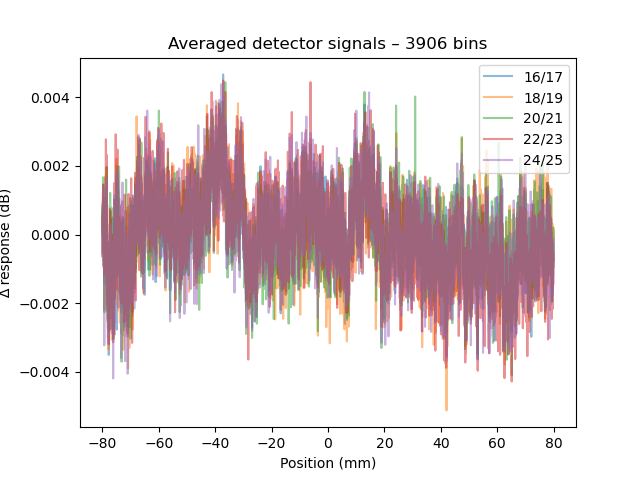

In [12]:
%matplotlib notebook
sys.path.append('~/home/rfsoc/fts/')
import position_correlator as cor
from glob import glob

# Use the FTS data to average together the detector timestream data based on position.
# Assumes the first FTS data file is fts_data_0.fits.
responses = cor.get_responses(p, 5, trim=True, clap_min_strength=1.0) # Combined I and Q from each detector
file_index = len(glob("/home/rfsoc/Documents/ftsdata/fts_data_*.fits")) - 1
fts_pts = cor.get_pos_time("/home/rfsoc/Documents/ftsdata/fts_data_"+str(file_index)+".fits", clap_end_time) # Position and time data from the FTS
bounce_times = cor.get_fts_bounces(fts_pts) # The minima and maxima on the FTS position curve
s21_vs_pos = cor.get_s21_vs_pos(responses, fts_pts) # Correlate each response sample with a position
avg_signals = cor.avg_passes(s21_vs_pos, int(packetrate*dist/speed)) # Average the response data using the given number of bins

# cor.plot_fts_pts(fts_pts)
# cor.plot_tones(responses, subplots=False, bounce_times=bounce_times)
cor.plot_average_signals(avg_signals, s21_vs_pos)

In [ ]:
%matplotlib notebook
cor.plot_average_signals(avg_signals, s21_vs_pos)

In [ ]:
%matplotlib notebook
cor.plot_fts_pts(fts_pts)

In [ ]:
# np.save("/home/rfsoc/Desktop/fts_data", p)
# np.save("/home/rfsoc/Desktop/fts_bounce_times", bounce_times)
512e6/(2.0**20)

In [ ]:
%matplotlib notebook
for i in range(3,4):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='r', label='%d'%i)

# plt.xlim(4,4.5)
plt.show()

In [ ]:
np.save('/home/rfsoc/rfsoc_result/Steve/230710/20230710_timestream_82mK_source_hand.npy',p)

In [ ]:
#p_sig=getNpackets_2(512*t_sec)

In [ ]:
#p_sig_wave_top=getNpackets_2(512*t_sec)

In [ ]:
p.shape

In [ ]:
#np.save('/home/rfsoc/rfsoc_result/Steve/230214/20230214_timestream_100mK_grid_notrotating.npy',p)

#np.save('/home/rfsoc/rfsoc_result/20230331_timestream_23dB_RFsoc1_handwaving.npy',p)

np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_10sec.npy',p)
np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_IR_source_50Hz_10sec.npy',p_sig)
np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_IR_source_50Hz_10sec_wave.npy',p_sig_wave)
np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_out_IR_source_50Hz_10sec_wave.npy',p_sig_wave_out)

In [ ]:
%matplotlib notebook
for i in range(3):
    plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='r', label='%d'%i)

    
for i in range(3):
    plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='b', label='%d'%i)
plt.ylabel('power')
    
#plt.plot( np.linspace(0,8,4001),p[:, 16], label="I",alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 17], label="Q",alpha=0.4)
#plt.plot( np.linspace(0,8,4001), p[:, 18], label="I_18",alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 19], label="Q_19",alpha=0.4)
#plt.plot( np.linspace(0,8,4001),p[:, 16+10*2], label="I_613", alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 17+10*2], label="Q_613", alpha=0.4)
#plt.legend()
#plt.savefig('stream_warmamp_on_off.png')

In [ ]:
%matplotlib notebook
i=1
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='r', label='det %d,no source'%i)


plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='b', label='det %d 5Hz source'%i)
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave[:, 16+i*2][100:]**2.0+p_sig_wave[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave[:, 16+i*2][100:]**2.0+p_sig_wave[:, 17+i*2][100:]**2.0)),
             alpha=0.8,color='g', label='det %d,5Hz source amp in box cable shaked'%i)
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave_out[:, 16+i*2][100:]**2.0+p_sig_wave_out[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave_out[:, 16+i*2][100:]**2.0+p_sig_wave_out[:, 17+i*2][100:]**2.0)),
            alpha=0.3,color='orange', label='det %d,5Hz source amp out of box cable shook'%i )
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave_top[:, 16+i*2][100:]**2.0+p_sig_wave_top[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave_top[:, 16+i*2][100:]**2.0+p_sig_wave_top[:, 17+i*2][100:]**2.0)),
            alpha=0.3,color='k', label='det %d,5Hz source amp out of cryostat cable shook'%i )
plt.ylabel('power')
plt.legend()

In [ ]:
ang_new=[]
ang_rev=[]
for i in range(14):
    I=p[:, 16+i*2]
    Q=p[:, 17+i*2]
    ang_mean=np.mean(np.arctan2(Q[5000:],I[5000:]))
    #I_prime=I*np.cos(ang_mean)+Q*np.sin(ang_mean)
    #Q_prime=Q*np.cos(ang_mean)-I*np.sin(ang_mean)
    Z=I+1j*Q
    Z_prime=Z*np.exp(-1j*ang_mean)
    I_prime=Z_prime.real
    Q_prime=Z_prime.imag
    Z_reverse=Z*np.exp(1j*ang_mean)
    I_rev=Z_reverse.real
    Q_rev=Z_reverse.imag
    ang_new.append(np.arctan2(Q_prime, I_prime))
    ang_rev.append(np.arctan2(Q_rev, I_rev))
    
ang_new=np.vstack(ang_new)
ang_rev=np.vstack(ang_rev)
    


In [ ]:
for i in range(14):
    plt.plot(np.linspace(0,20,10000)[100:],ang_new[i,:][100:],alpha=0.3,color='r')
    plt.plot(np.linspace(0,20,10000)[100:],ang_rev[i,:][100:],alpha=0.3,color='b')

In [ ]:
pow=p[:, 16+6*2][100:]**2.0+p[:, 17+6*2][100:]**2.0
pow_sel=pow[4000:]
print (np.std(pow_sel))
print (4e10/np.std(pow_sel))

In [ ]:
%matplotlib notebook
for i in range(15):
    if i!=12: continue
    plt.plot(np.linspace(0,16,10000)[100:],np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])-np.mean(np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])),label='%d'%i)
    
plt.legend()

In [ ]:
phase=np.arctan2(p[:, 16+6*2][100:],p[:, 17+6*2][100:])
phase_sel=phase[4000:]
snr=0.12/np.std(phase_sel)
samp=512e6/2**20 #Hz
snr_thz=snr*samp**0.5
print (snr_thz)
load=15*1.38e-23*60e9
NEP=load/snr_thz
print (NEP)


In [ ]:
phase=np.arctan2(p[:, 16+2*2][100:],p[:, 17+2*2][100:])
phase_sel=phase[4000:]
snr=0.09/np.std(phase_sel)
samp=512e6/2**20 #Hz 
snr_thz=snr*samp**0.5
print (snr_thz)
load=15*1.38e-23*60e9
NEP=load/snr_thz
print (NEP)

In [ ]:
p_ln2=getNpackets_2(8000)

In [ ]:
%matplotlib notebook
for i in range(17):
    if i!=6: continue
    plt.plot(np.linspace(0,16,8000)[100:],10*np.log10(p_ln2[:, 16+i*2][100:]**2.0+p_ln2[:, 17+i*2][100:]**2.0),alpha=0.3, label='%d'%i)
plt.legend()


In [ ]:
%matplotlib notebook
for i in range(15):
    if i!=6: continue
    plt.plot(np.linspace(0,16,8000)[100:],np.arctan2(p_ln2[:, 16+i*2][100:],p_ln2[:, 17+i*2][100:])-np.mean(np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])),label='%d'%i)
    
plt.legend()

In [ ]:
pow=p_ln2[:, 16+6*2][100:]**2.0+p_ln2[:, 17+6*2][100:]**2.0
pow_sel=pow[4000:]
print (np.std(pow_sel))

In [ ]:
p_shake=getNpackets_2(4000)

In [ ]:
%matplotlib notebook
for i in range(22):
    plt.plot(np.linspace(0,8,4000)[100:],p_shake[:, 16+i*2][100:]**2.0+p_shake[:, 17+i*2][100:]**2.0, label='%d'%i)
    
plt.legend()

In [ ]:
%matplotlib notebook
for i in range(13):
    plt.plot(np.linspace(0,8,4001)[100:],p_nomag[:, 16+i*2][100:], label='%d'%i)
    
plt.legend()

In [ ]:
%matplotlib notebook
i=5
plt.plot(np.linspace(0,8,4001),p[:, 16+i*2]**2.0+p[:, 17+i*2]**2.0)  

In [ ]:
def get_noise(p,ch):
    pow_ch=p[:, 16+ch*2]**2.0+p[:, 17+ch*2]**2.0
    pow_ch_sel=pow_ch[100:]
    std_ch=np.std(pow_ch_sel)
    print (std_ch)
    return std_ch

In [ ]:
std_coax=get_noise(p,5)
std_off/std_coax

In [ ]:
pow_5=p[:, 16+i*2]**2.0+p[:, 17+i*2]**2.0
pow_5_sel=pow_5[3000:]
std=np.std(pow_5_sel)
print (std)
print (0.5e9/std)

In [ ]:
%matplotlib notebook
plt.plot( np.linspace(0,8,4001)[15:], p[:, 18][15:], label="I_18",alpha=0.4)
plt.plot(  np.linspace(0,8,4001)[15:],p[:, 19][15:], label="Q_19",alpha=0.4)
plt.legend()

In [ ]:
%matplotlib notebook
plt.plot( np.linspace(0,8,4001)[15:], p[:, 18][15:]**2+p[:,19][15:]**2, label="pow",alpha=0.4)
#plt.ylim(3e8,2.13e9)


In [ ]:
data_off=np.load('20230203_packets_wave_LO601_offres.npy')

In [ ]:
i=5
pow_5_off=data_off[:, 16+i*2]**2.0+data_off[:, 17+i*2]**2.0
pow_5_sel_off=pow_5_off[15:]
std_off=np.std(pow_5_sel_off)
print (std/std_off)

In [ ]:
np.save('20230203_packets_wave_LO600_onres.npy',p)

In [ ]:
#hand width 6cm, window is 25cm in diameter
25*6/(25**2*0.25*np.pi)
#assuming a 273+37=310K, 15k delta T
peak=3.5e8
baseline=3.1e8
var=0.05e8/2**0.5
snr=(peak-baseline)/var
BW=512e6/2**20 #in Hz
snr_hz=snr*np.sqrt(BW)
dp=1*1.38e-23*50e9*0.1*0.7*0.8#if 10.5icm, resulting 50GHz BW
NEP=dp/snr
NEP
#250-310GHz 
dp=293*1.38e-23*50e9*0.1*0.7*0.8#if 10.5icm 



In [ ]:
file='tmp/freqs_vna_20221011T225216Z.npy'
freq_data=np.load(file)

In [ ]:
#plt.plot(p[:, 0]**2.0+p[:, 1]**2.0, label='ch0001')
#plt.plot(p[:, 1998]**2.0+p[:, 1999]**2.0,label='ch1000')
plt.plot(p[:, 16]**2.0+p[:, 17]**2.0, label='ch0001')
plt.plot(p[:, 2014]**2.0+p[:, 2015]**2.0,label='ch1000')
plt.legend()
#plt.yscale('log')

In [ ]:
freq_data+=1e9

In [ ]:
for i in range(1000):
    plt.scatter(freq_data[i],20*np.log10((p[10,i*2+16]**2+p[10,i*2+17]**2)**0.5), alpha=0.1, color='b')
#freq_data

In [ ]:
6.18457736e+08-